In [1]:
import sys
from pathlib import Path

# Locate project root by walking up until .git is found, then make
# config.py importable regardless of Jupyter's working directory.
_root = Path.cwd().resolve()
while not (_root / ".git").exists():
    if _root == _root.parent:
        raise FileNotFoundError("Could not locate project root (.git not found)")
    _root = _root.parent
sys.path.insert(0, str(_root))

from config import DATA_PROCESSED, MODELS_DIR, RESULTS_DIR
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt

df = pd.read_csv(DATA_PROCESSED / "diabetic_cohort_preprocessed.csv")
X = df.drop(columns=['readmission_30', 'patient_id'])

model = joblib.load(MODELS_DIR / "best_model.pkl")
scaler = joblib.load(MODELS_DIR / "scaler.pkl")
X_scaled = scaler.transform(X)

print(f"Loaded model: {type(model).__name__}")

c:\Users\hamna\Desktop\MediAlert\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded model: XGBClassifier


In [2]:
# Build the explainer

background = X_scaled[:100]
explainer = shap.Explainer(model.predict_proba, background, feature_names=list(X.columns))
print(f"Explainer type selected: {type(explainer).__name__}")

Explainer type selected: PermutationExplainer


PermutationExplainer explainer: 201it [00:22,  8.98it/s]                         
C:\Users\hamna\AppData\Local\Temp\ipykernel_12268\2422105815.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 1], features=sample_raw, feature_names=list(X.columns), show=False)


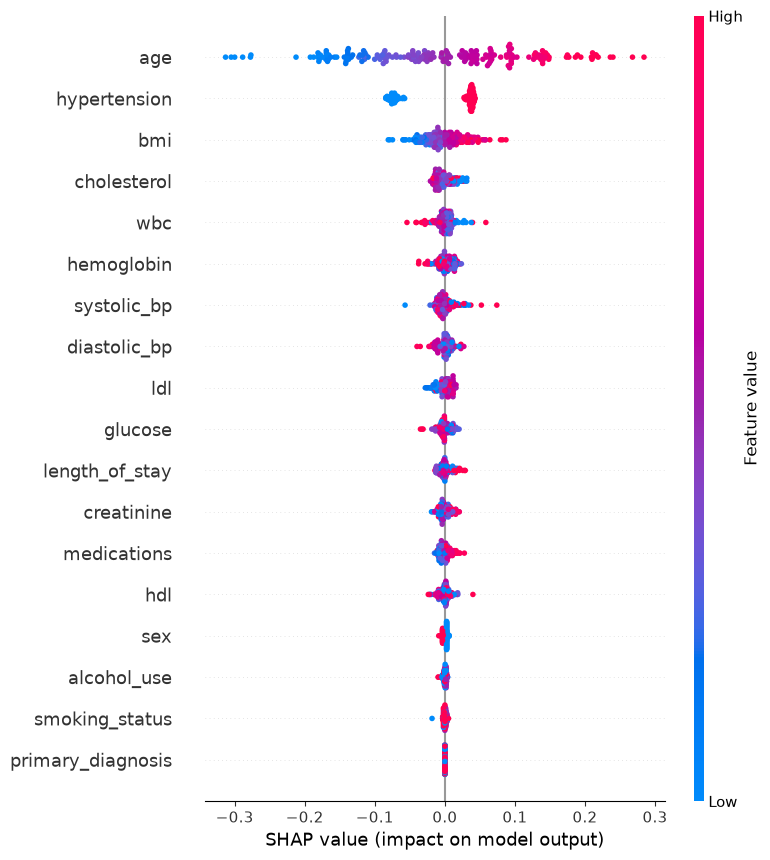

In [3]:
# SHAP value on a sample

sample_scaled = X_scaled[:200]
sample_raw = X.iloc[:200]
shap_values = explainer(sample_scaled)

# Show real feature values on the plot, not the scaled ones used for computation
shap_values.data = sample_raw.values

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / "figures").mkdir(parents=True, exist_ok=True)
fig = plt.figure()
shap.summary_plot(shap_values[:, :, 1], features=sample_raw, feature_names=list(X.columns), show=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "shap_beeswarm.png", dpi=150)
plt.show()

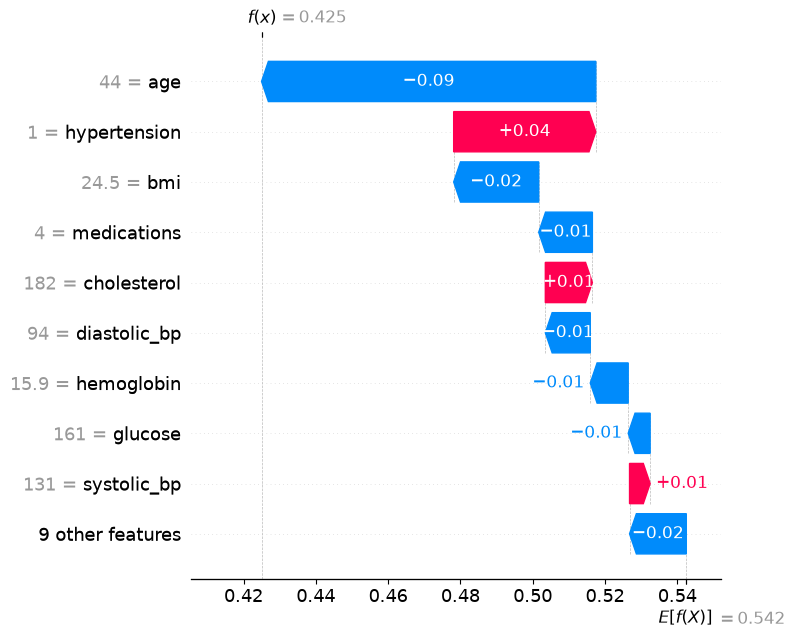

In [4]:
# Individual patient waterfall explanation

single = shap_values[0, :, 1]
fig = plt.figure()
shap.plots.waterfall(single, show=False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "shap_waterfall_example.png", dpi=150)
plt.show()